# Brain Tumor — Feature Parameter Selection + Benchmark
## Phase 1: Optimal GLCM · LBP · DWT parameters via Class-Separability Metrics
## Phase 2: Full SVM · KNN · RF Benchmark with optimal parameters

---

### Strategy

Training a full classifier for every parameter combination is expensive.
Instead we use three **classifier-free separability metrics** to score each
feature configuration in seconds:

| Metric | What it measures | Why useful |
|--------|-----------------|------------|
| **Fisher's Discriminant Ratio (FDR)** | Between-class variance ÷ within-class variance per feature (averaged) | High FDR = features naturally cluster by class |
| **Mutual Information (MI)** | Statistical dependency between each feature and the class label | Captures non-linear relationships |
| **Davies-Bouldin Index (DBI)** | Cluster compactness & separation in feature space | Lower = better separated classes |

Once the best parameters are selected, a single model benchmark is run with those parameters.

### Parameters explored

| Feature | Parameters |
|---------|-----------|
| **GLCM** | distances, angles, levels, symmetric |
| **LBP** | P (sampling points), R (radius), method |
| **DWT** | wavelet family, decomposition levels |


## 1. Setup

In [45]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn scikit-image scipy pywavelets tqdm pillow

Note: you may need to restart the kernel to use updated packages.


In [46]:
import time, warnings, itertools, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
from pathlib import Path

from scipy.stats import skew, kurtosis

from sklearn.preprocessing import StandardScaler, label_binarize, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, davies_bouldin_score,
                             silhouette_score)
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.filters import gaussian
from skimage import exposure
from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops
import pywt

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", font_scale=1.05)

print("All imports OK.")


All imports OK.


## 2. Configuration

Edit the parameter grids here to control which values are explored.

In [47]:
from pathlib import Path

# ── Dataset ────────────────────────────────────────────────────────────────
DATASET_ROOT = Path("Dataset/BrainTumorDetection&Classification/BrainTumorDetection&Classification")
DATASET_DIR  = DATASET_ROOT / "images_by_class"
TARGET_SIZE  = (128, 128)
USE_CLAHE    = True
TEST_SIZE    = 0.20
MAX_SAMPLES_PER_CLASS = None   # set e.g. 400 for faster runs

# ── Local cache (faster reruns) ───────────────────────────────────────────
CACHE_DIR = Path("cache/brain_tumor")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FORCE_RECOMPUTE_CACHE = False

# ── Output directory for all figures ───────────────────────────────────────
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════
# PARAMETER GRIDS — edit these to explore different values
# ══════════════════════════════════════════════════════════════════════════

# ── GLCM parameters ───────────────────────────────────────────────────────
# distances : pixel offsets — small distances capture fine texture,
#             large distances capture coarser structure
# angles    : directions to compute co-occurrence (radians)
# levels    : number of grey-level bins (higher = finer but noisier)
# symmetric : whether to average P(i,j) with P(j,i)
GLCM_GRID = {
    "distances": [
        [1],
        [1, 2],
        [1, 2, 4],
        [1, 2, 4, 8],
        [2, 4],
        [4, 8],
    ],
    "angles": [
        [0],
        [0, np.pi/2],
        [0, np.pi/4, np.pi/2, 3*np.pi/4],          # standard 4 angles
        [0, np.pi/6, np.pi/3, np.pi/2, 2*np.pi/3, 5*np.pi/6],  # 6 angles
    ],
    "levels": [64, 128, 256],
    "symmetric": [True, False],
}

# ── LBP parameters ────────────────────────────────────────────────────────
# P      : number of sampling points around each pixel
#          more points = finer texture description, longer vector
# R      : radius of the circular neighbourhood in pixels
# method : "uniform"     — only patterns with ≤2 bit transitions (compact)
#          "nri_uniform" — non-rotation-invariant uniform patterns
#          "ror"         — rotation-invariant but not uniform
#          "default"     — standard LBP (all 2^P patterns)
LBP_GRID = {
    "P": [8, 12, 16, 24],
    "R": [1, 2, 3],
    "method": ["uniform", "nri_uniform", "ror"],
}

# ── DWT parameters ────────────────────────────────────────────────────────
# wavelet : wavelet family — affects smoothness and frequency localisation
#   haar  : simplest, discontinuous
#   db1-4 : Daubechies family (db1 = haar); more vanishing moments = smoother
#   sym2  : Symlets (near-symmetric Daubechies)
#   coif1 : Coiflets (higher vanishing moments, good for smooth signals)
#   bior1.3: Biorthogonal (symmetric, used in JPEG 2000)
# level   : decomposition depth — more levels = coarser frequency bands
#           but sub-bands become very small on 128×128 images (max ~5 levels)
DWT_GRID = {
    "wavelet": ["haar", "db1", "db2", "db4", "sym2", "coif1", "bior1.3"],
    "level":   [1, 2, 3],
}

# ── Model benchmark grids (Phase 2) ───────────────────────────────────────
CV_FOLDS = 3
CV = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

MODEL_GRIDS = {
    # SVM: linear + rbf; gamma only for rbf
    "SVM": [
        {"kernel": ["linear"], "C": [0.1, 1, 10, 100]},
        {"kernel": ["rbf"], "C": [0.1, 1, 10, 100], "gamma": ["scale", 1e-2, 1e-1]},
    ],
    # KNN: vary k, distance metric, and weighting
    "KNN": {
        "n_neighbors": [3, 5, 7, 9, 11],
        "metric": ["euclidean", "manhattan"],
        "weights": ["uniform", "distance"],
    },
    # Random Forest: trees + depth + feature sampling
    "RF": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20],
        "max_features": ["sqrt", "log2"],
    },
}

PALETTE = {"SVM": sns.color_palette("Set2")[0],
           "KNN": sns.color_palette("Set2")[1],
           "RF":  sns.color_palette("Set2")[2]}

# Count total configurations
n_glcm = (len(GLCM_GRID["distances"]) * len(GLCM_GRID["angles"]) *
           len(GLCM_GRID["levels"])    * len(GLCM_GRID["symmetric"]))
n_lbp  = len(LBP_GRID["P"]) * len(LBP_GRID["R"]) * len(LBP_GRID["method"])
n_dwt  = len(DWT_GRID["wavelet"]) * len(DWT_GRID["level"])

print(f"GLCM configurations : {n_glcm}")
print(f"LBP  configurations : {n_lbp}")
print(f"DWT  configurations : {n_dwt}")
print(f"Total feature configs: {n_glcm + n_lbp + n_dwt}")


GLCM configurations : 144
LBP  configurations : 36
DWT  configurations : 21
Total feature configs: 201


## 3. Preprocessing & Data Loading

Loading dataset from cache: cache\brain_tumor\dataset_3a3180af56.npz
Classes (3): ['Glioma', 'Meningioma', 'Pituitary Tumor']
Train: (1200, 128, 128)   Test: (300, 128, 128)


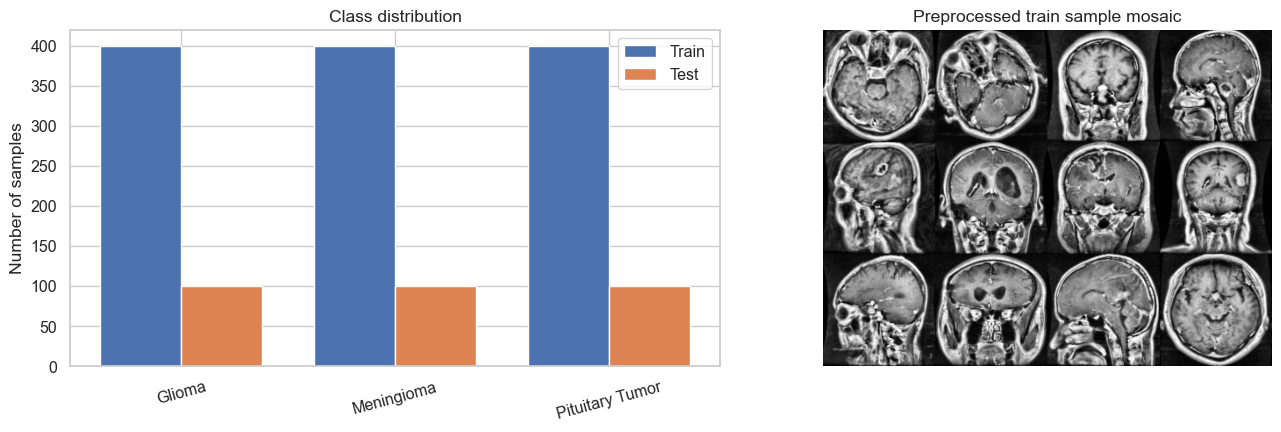

In [48]:
def crop_black(img, thr=0.05):
    mask = img > thr
    if not np.any(mask): return img
    ys, xs = np.where(mask)
    return img[ys.min():ys.max()+1, xs.min():xs.max()+1]

def preprocess_mri(img):
    if img.ndim == 3: img = rgb2gray(img)
    img = img.astype(np.float32)
    if img.max() > 1.0: img /= 255.0
    img = crop_black(img)
    img = resize(img, TARGET_SIZE, anti_aliasing=True, preserve_range=True).astype(np.float32)
    img = gaussian(img, sigma=0.5, preserve_range=True).astype(np.float32)
    mn, mx = img.min(), img.max()
    img = (img - mn) / (mx - mn + 1e-9)
    if USE_CLAHE:
        img = np.clip(exposure.equalize_adapthist(img, clip_limit=0.02), 0, 1)
    return img.astype(np.float32)

def load_dataset(dataset_dir, max_per_class=None):
    class_names = sorted([d.name for d in dataset_dir.iterdir() if d.is_dir()])
    rng = np.random.default_rng(SEED)
    X_list, y_list = [], []
    for idx, cls in enumerate(class_names):
        paths = [p for p in (dataset_dir/cls).iterdir()
                 if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp"}]
        if max_per_class and len(paths) > max_per_class:
            paths = [paths[i] for i in rng.choice(len(paths), max_per_class, replace=False)]
        for p in tqdm(paths, desc=f"  {cls}"):
            try:
                X_list.append(preprocess_mri(imread(p)))
                y_list.append(idx)
            except Exception: pass
    return np.stack(X_list).astype(np.float32), np.array(y_list, np.int32), class_names

cache_tag = f"sz{TARGET_SIZE[0]}x{TARGET_SIZE[1]}_clahe{int(USE_CLAHE)}_test{TEST_SIZE}_max{MAX_SAMPLES_PER_CLASS}"
cache_hash = hashlib.md5(cache_tag.encode("utf-8")).hexdigest()[:10]
dataset_cache_path = CACHE_DIR / f"dataset_{cache_hash}.npz"

if dataset_cache_path.exists() and not FORCE_RECOMPUTE_CACHE:
    print(f"Loading dataset from cache: {dataset_cache_path}")
    ds = np.load(dataset_cache_path, allow_pickle=True)
    X_train_raw = ds["X_train_raw"]
    X_test_raw = ds["X_test_raw"]
    y_train = ds["y_train"]
    y_test = ds["y_test"]
    class_names = list(ds["class_names"])
    X_all = np.concatenate([X_train_raw, X_test_raw], axis=0)
    y_all = np.concatenate([y_train, y_test], axis=0)
else:
    print("Loading dataset from images …")
    X_all, y_all, class_names = load_dataset(DATASET_DIR, MAX_SAMPLES_PER_CLASS)
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_all, y_all, test_size=TEST_SIZE, random_state=SEED, stratify=y_all
    )
    np.savez_compressed(
        dataset_cache_path,
        X_train_raw=X_train_raw,
        X_test_raw=X_test_raw,
        y_train=y_train,
        y_test=y_test,
        class_names=np.array(class_names, dtype=object),
    )
    print(f"Saved dataset cache: {dataset_cache_path}")

n_classes = len(class_names)

print(f"Classes ({n_classes}): {class_names}")
print(f"Train: {X_train_raw.shape}   Test: {X_test_raw.shape}")

# ── Dataset plotting: class distribution + sample images ─────────────────
train_counts = np.bincount(y_train, minlength=n_classes)
test_counts = np.bincount(y_test, minlength=n_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
x = np.arange(n_classes)
width = 0.38
axes[0].bar(x - width / 2, train_counts, width=width, label="Train")
axes[0].bar(x + width / 2, test_counts, width=width, label="Test")
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names, rotation=15)
axes[0].set_title("Class distribution")
axes[0].set_ylabel("Number of samples")
axes[0].legend()

n_show = min(12, len(X_train_raw))
idx = np.random.choice(len(X_train_raw), size=n_show, replace=False)
grid_rows, grid_cols = 3, 4
sample_fig = np.zeros((TARGET_SIZE[0] * grid_rows, TARGET_SIZE[1] * grid_cols), dtype=np.float32)
for k, i in enumerate(idx):
    r, c = divmod(k, grid_cols)
    y0, y1 = r * TARGET_SIZE[0], (r + 1) * TARGET_SIZE[0]
    x0, x1 = c * TARGET_SIZE[1], (c + 1) * TARGET_SIZE[1]
    sample_fig[y0:y1, x0:x1] = X_train_raw[i]
axes[1].imshow(sample_fig, cmap="gray")
axes[1].set_title("Preprocessed train sample mosaic")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 4. Class-Separability Metrics
### Why not just use a classifier?

Training even a simple KNN on every parameter combination would take hours.
These three metrics evaluate feature quality in **milliseconds** by directly
measuring how well the feature distributions separate the classes.

```
Fisher's Discriminant Ratio (FDR)
  = mean over all features of:
      (between-class variance) / (within-class variance + ε)

  → High FDR means class means are far apart relative to within-class spread
  → Equivalent to the numerator of LDA's objective function

Mutual Information (MI)
  = average MI(feature_i ; class_label) over all features
  → Captures non-linear relationships that FDR misses
  → Scale-invariant — robust to feature magnitude differences

Davies-Bouldin Index (DBI)  [lower = better]
  = average ratio of (within-cluster scatter) to (between-cluster distance)
    computed in the full feature space (using PCA to 20 dims for speed)
  → Directly measures cluster quality in feature space
  → Lower DBI = more compact, better-separated class clusters
```


In [49]:
def fisher_discriminant_ratio(X, y):
    # Compute the mean Fisher Discriminant Ratio across all features.
    # FDR = between-class variance / within-class variance.
    # A higher value means features separate classes better.
    classes = np.unique(y)
    grand_mean = X.mean(axis=0)
    n_features = X.shape[1]

    between = np.zeros(n_features)
    within  = np.zeros(n_features)

    for c in classes:
        Xc = X[y == c]
        n_c = len(Xc)
        class_mean = Xc.mean(axis=0)
        # Between-class: weighted distance of class mean from grand mean
        between += n_c * (class_mean - grand_mean) ** 2
        # Within-class: variance of samples inside this class
        within  += ((Xc - class_mean) ** 2).sum(axis=0)

    # Avoid division by zero with a small epsilon
    fdr_per_feature = between / (within + 1e-10)
    return float(np.mean(fdr_per_feature))


def mutual_information_score(X, y):
    # Average mutual information between each feature and the class label.
    # Uses sklearn's implementation which handles discrete classes automatically.
    # Returns a scalar: higher = features carry more information about the label.
    mi = mutual_info_classif(X, y, random_state=SEED, n_neighbors=5)
    return float(np.mean(mi))


def davies_bouldin(X, y, max_dim=20):
    # Davies-Bouldin Index on a PCA-reduced version of X.
    # Lower = better separated classes.
    # We reduce to max_dim components first for speed (avoids O(n²) in high-D).
    n_comp = min(max_dim, X.shape[1], X.shape[0] - 1)
    Xr = PCA(n_components=n_comp, random_state=SEED).fit_transform(X)
    return float(davies_bouldin_score(Xr, y))


def evaluate_features(X, y, label="", verbose=False):
    # Apply all three metrics; return a dict.
    # X should already be standardised for fair comparison across configs.
    sc  = StandardScaler()
    Xs  = sc.fit_transform(X)
    fdr = fisher_discriminant_ratio(Xs, y)
    mi  = mutual_information_score(Xs, y)
    dbi = davies_bouldin(Xs, y)
    if verbose:
        print(f"  {label:40s}  FDR={fdr:.4f}  MI={mi:.4f}  DBI={dbi:.4f}")
    return {"FDR": fdr, "MI": mi, "DBI": dbi}


# Quick sanity-check on a dummy random feature matrix
_X_dummy = np.random.randn(len(y_train), 20)
_res = evaluate_features(_X_dummy, y_train, "random baseline", verbose=True)
print("Sanity check passed — metrics computed successfully.")


  random baseline                           FDR=0.0016  MI=0.0070  DBI=32.8890
Sanity check passed — metrics computed successfully.


## 5. Parameterised Feature Extraction Functions

In [50]:
# ── GLCM extractor (fully parameterised) ──────────────────────────────────
def extract_glcm(images, distances, angles, levels, symmetric):
    # Compute GLCM-based texture features for a list of images.
    # distances : list of pixel offsets
    # angles    : list of angles in radians
    # levels    : number of grey-level bins
    # symmetric : whether to symmetrise the co-occurrence matrix
    #
    # Returns one row per image with 6 GLCM properties averaged over all
    # (distance, angle) pairs.
    props = ["contrast","dissimilarity","homogeneity","energy","correlation","ASM"]
    rows = []
    for img in images:
        u8 = (img * 255).astype(np.uint8)
        glcm = graycomatrix(u8, distances=distances, angles=angles,
                            levels=levels, symmetric=symmetric, normed=True)
        row = [graycoprops(glcm, p).mean() for p in props]
        rows.append(row)
    return np.array(rows, dtype=np.float32)


# ── LBP extractor (fully parameterised) ───────────────────────────────────
def extract_lbp(images, P, R, method):
    # Compute LBP histogram features for a list of images.
    # P      : number of circularly-symmetric neighbour set points
    # R      : radius of circle
    # method : LBP variant — affects number of unique patterns
    #   "uniform"     → P+2 bins  (patterns with ≤2 bit transitions)
    #   "nri_uniform" → P+2 bins  (non-rotation-invariant uniform)
    #   "ror"         → 2^P bins  (rotation-invariant)
    #   "default"     → 2^P bins  (standard LBP)
    if method in ("uniform", "nri_uniform"):
        n_bins = P + 2
        bin_edges = np.arange(0, n_bins + 1)
    else:
        n_bins = 2 ** P
        bin_edges = np.arange(0, n_bins + 1)

    rows = []
    for img in images:
        lbp = local_binary_pattern(img, P=P, R=R, method=method)
        hist, _ = np.histogram(lbp.ravel(), bins=bin_edges, density=True)
        rows.append(hist.astype(np.float32))
    return np.array(rows, dtype=np.float32)


# ── DWT extractor (fully parameterised) ───────────────────────────────────
def _band_stats(b):
    # Four statistics per wavelet sub-band:
    # mean (dc level), std (spread), energy (power), entropy (diversity)
    v = b.ravel().astype(np.float32)
    h, _ = np.histogram(v, bins=64, density=True)
    h = (h + 1e-12); h /= h.sum()
    return [v.mean(), v.std(), np.mean(v**2), -(h*np.log2(h)).sum()]

def extract_dwt(images, wavelet, level):
    # Apply multi-level 2-D DWT and collect statistics from every sub-band.
    # wavelet : wavelet family string (e.g. "db2", "haar")
    # level   : decomposition depth
    #   Level 1 → 4 sub-bands (LL, LH, HL, HH)
    #   Level 2 → 7 sub-bands (LL2, LH2, HL2, HH2, LH1, HL1, HH1)
    #   Level L → 3L+1 sub-bands total
    #
    # For each sub-band we extract 4 stats → 4*(3L+1) total features
    rows = []
    for img in images:
        coeffs = pywt.wavedec2(img, wavelet=wavelet, level=level)
        # coeffs[0]  = LL (approximation at deepest level)
        # coeffs[k]  = (LH, HL, HH) for scale k
        feats = _band_stats(coeffs[0])          # LL approximation
        for detail_tuple in coeffs[1:]:         # detail coefficients
            for band in detail_tuple:           # LH, HL, HH
                feats.extend(_band_stats(band))
        rows.append(np.array(feats, np.float32))
    return np.array(rows, dtype=np.float32)


print("Feature extractors defined.")
print(f"  GLCM output size  : 6 properties (always)")
print(f"  LBP  output size  : P+2 or 2^P depending on method")
print(f"  DWT  output size  : 4*(3*level+1) features")
print(f"    e.g. level=1 → {4*(3*1+1)} features")
print(f"    e.g. level=2 → {4*(3*2+1)} features")
print(f"    e.g. level=3 → {4*(3*3+1)} features")


Feature extractors defined.
  GLCM output size  : 6 properties (always)
  LBP  output size  : P+2 or 2^P depending on method
  DWT  output size  : 4*(3*level+1) features
    e.g. level=1 → 16 features
    e.g. level=2 → 28 features
    e.g. level=3 → 40 features


## 6. Phase 1A — GLCM Parameter Selection

In [51]:
print("Scanning GLCM parameter space …")
glcm_rows = []

configs = list(itertools.product(
    GLCM_GRID["distances"],
    GLCM_GRID["angles"],
    GLCM_GRID["levels"],
    GLCM_GRID["symmetric"],
))
print(f"Total GLCM configurations: {len(configs)}")

for dist, ang, lvl, sym in tqdm(configs, desc="GLCM"):
    label = (f"d={dist} a={len(ang)}ang "
             f"l={lvl} sym={sym}")
    try:
        X_feat = extract_glcm(X_train_raw, dist, ang, lvl, sym)
        metrics = evaluate_features(X_feat, y_train)
        glcm_rows.append({
            "distances":  str(dist),
            "n_distances": len(dist),
            "angles":     str([round(a,3) for a in ang]),
            "n_angles":   len(ang),
            "levels":     lvl,
            "symmetric":  sym,
            "n_features": X_feat.shape[1],
            "label":      label,
            **metrics,
        })
    except Exception as e:
        print(f"  SKIP {label}: {e}")

glcm_df = pd.DataFrame(glcm_rows)

# ── Composite score: normalise each metric then combine ───────────────────
# FDR ↑ better, MI ↑ better, DBI ↓ better (invert it)
mms = MinMaxScaler()
glcm_df["FDR_n"]  = mms.fit_transform(glcm_df[["FDR"]])
glcm_df["MI_n"]   = mms.fit_transform(glcm_df[["MI"]])
glcm_df["DBI_n"]  = 1 - mms.fit_transform(glcm_df[["DBI"]])   # invert
glcm_df["score"]  = (glcm_df["FDR_n"] + glcm_df["MI_n"] + glcm_df["DBI_n"]) / 3

glcm_df = glcm_df.sort_values("score", ascending=False).reset_index(drop=True)

print("\nTop 10 GLCM configurations:")
display(glcm_df[["distances","n_angles","levels","symmetric",
                 "n_features","FDR","MI","DBI","score"]].head(10).round(4))

# ── Best config ────────────────────────────────────────────────────────────
best_glcm = glcm_df.iloc[0]
BEST_GLCM_DIST = eval(best_glcm["distances"])
BEST_GLCM_ANG  = eval(best_glcm["angles"])
BEST_GLCM_LVL  = int(best_glcm["levels"])
BEST_GLCM_SYM  = bool(best_glcm["symmetric"])

print(f"\n✓ Best GLCM config:")
print(f"  distances : {BEST_GLCM_DIST}")
print(f"  angles    : {BEST_GLCM_ANG}")
print(f"  levels    : {BEST_GLCM_LVL}")
print(f"  symmetric : {BEST_GLCM_SYM}")
print(f"  score     : {best_glcm['score']:.4f}")


Scanning GLCM parameter space …
Total GLCM configurations: 144


GLCM:   0%|          | 0/144 [00:00<?, ?it/s]

  SKIP d=[1] a=1ang l=64 sym=True: The maximum grayscale value in the image should be smaller than the number of levels.
  SKIP d=[1] a=1ang l=64 sym=False: The maximum grayscale value in the image should be smaller than the number of levels.
  SKIP d=[1] a=1ang l=128 sym=True: The maximum grayscale value in the image should be smaller than the number of levels.
  SKIP d=[1] a=1ang l=128 sym=False: The maximum grayscale value in the image should be smaller than the number of levels.
  SKIP d=[1] a=2ang l=64 sym=True: The maximum grayscale value in the image should be smaller than the number of levels.
  SKIP d=[1] a=2ang l=64 sym=False: The maximum grayscale value in the image should be smaller than the number of levels.
  SKIP d=[1] a=2ang l=128 sym=True: The maximum grayscale value in the image should be smaller than the number of levels.
  SKIP d=[1] a=2ang l=128 sym=False: The maximum grayscale value in the image should be smaller than the number of levels.
  SKIP d=[1] a=4ang l=64

,distances,n_angles,levels,symmetric,n_features,FDR,MI,DBI,score
0,"[1, 2, 4, 8]",1,256,False,6,0.2762,0.1938,4.0444,0.7564
1,"[1, 2, 4, 8]",1,256,True,6,0.2762,0.1904,4.0460,0.7372
2,[1],1,256,False,6,0.3154,0.2043,4.8726,0.7329
3,[1],1,256,True,6,0.3156,0.2009,4.8736,0.7144
4,[1],2,256,True,6,0.2791,0.1895,4.4730,0.6516
5,[1],2,256,False,6,0.2788,0.1886,4.4728,0.6459
6,"[4, 8]",1,256,False,6,0.2391,0.1689,3.5705,0.6323
7,"[4, 8]",1,256,True,6,0.2384,0.1667,3.5720,0.6186
8,[1],4,256,False,6,0.2743,0.1863,4.5753,0.6020
9,[1],4,256,True,6,0.2745,0.1828,4.5755,0.5828



✓ Best GLCM config:
  distances : [1, 2, 4, 8]
  angles    : [0]
  levels    : 256
  symmetric : False
  score     : 0.7564


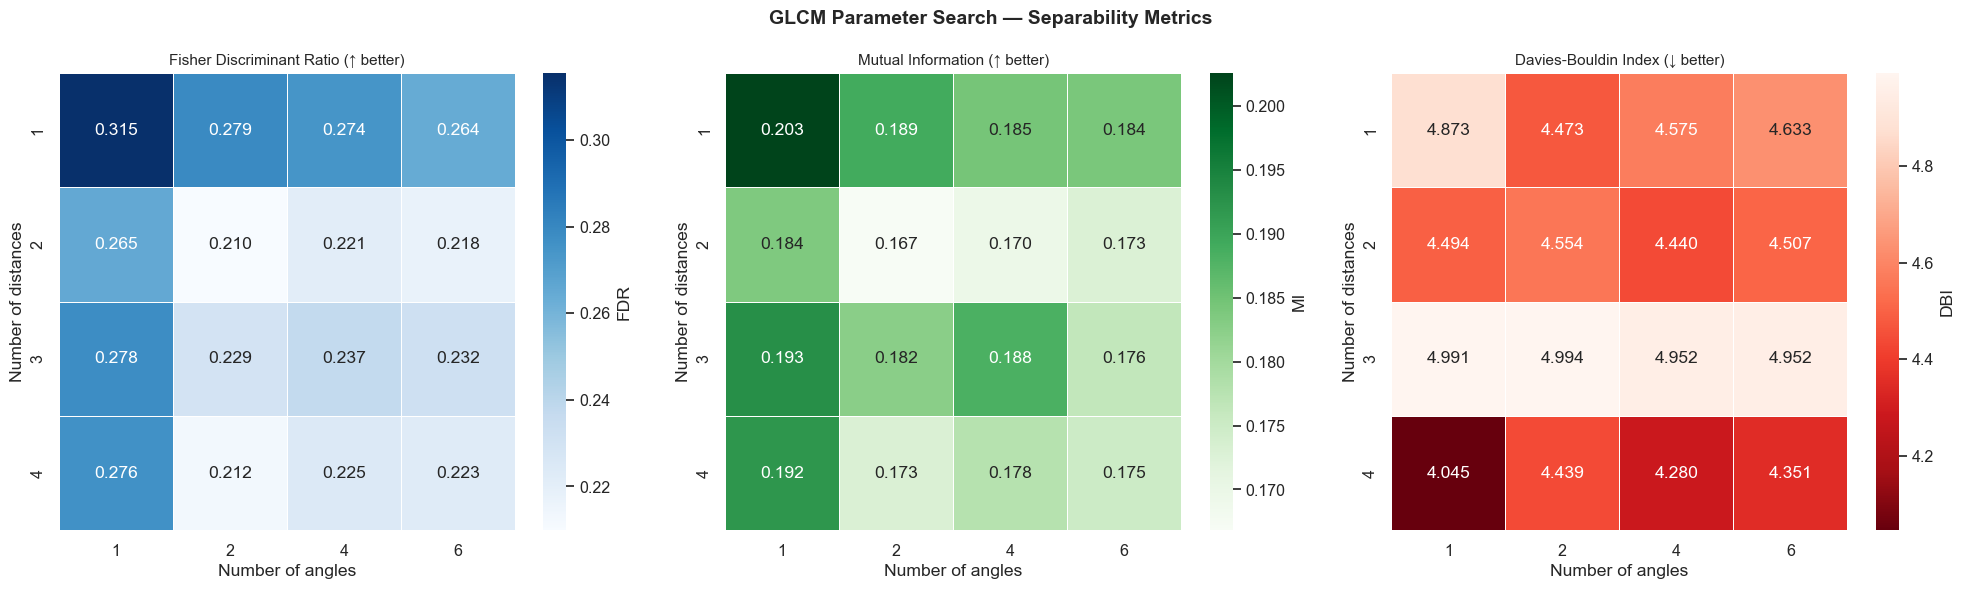

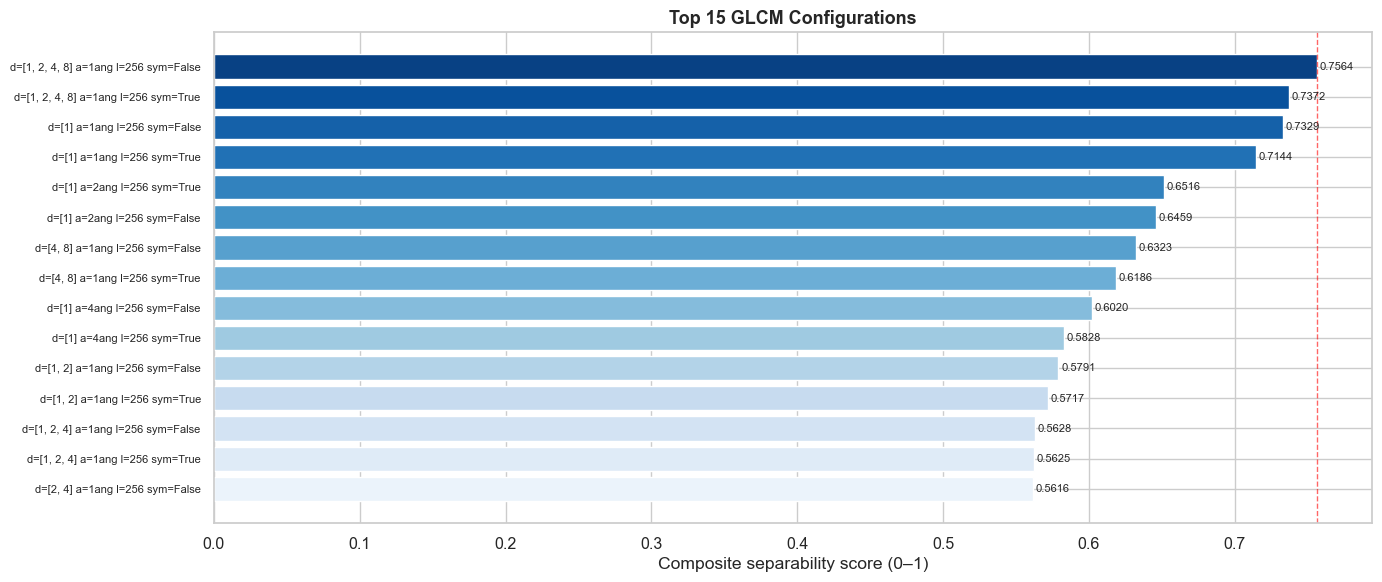

Saved: glcm_param_search.png, glcm_top15.png


In [52]:
# ── GLCM visualisation ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("GLCM Parameter Search — Separability Metrics", fontsize=14, fontweight="bold")

metrics_plot = [("FDR","Fisher Discriminant Ratio (↑ better)","Blues"),
                ("MI", "Mutual Information (↑ better)",       "Greens"),
                ("DBI","Davies-Bouldin Index (↓ better)",     "Reds")]

for ax, (met, title, cmap) in zip(axes, metrics_plot):
    # Pivot: group by n_distances vs n_angles, average over levels & symmetric
    piv = glcm_df.groupby(["n_distances","n_angles"])[met].mean().unstack()
    if met == "DBI":
        # For DBI invert colour (lower=better should be dark)
        sns.heatmap(piv, ax=ax, cmap=cmap+"_r", annot=True, fmt=".3f",
                    linewidths=0.5, cbar_kws={"label": met})
    else:
        sns.heatmap(piv, ax=ax, cmap=cmap, annot=True, fmt=".3f",
                    linewidths=0.5, cbar_kws={"label": met})
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Number of angles")
    ax.set_ylabel("Number of distances")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "glcm_param_search.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Score bar chart: top 15 configs ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
top15 = glcm_df.head(15)
bars = ax.barh(range(15)[::-1], top15["score"],
               color=sns.color_palette("Blues_r", 15))
ax.set_yticks(range(15)[::-1])
ax.set_yticklabels(top15["label"], fontsize=8)
ax.set_xlabel("Composite separability score (0–1)")
ax.set_title("Top 15 GLCM Configurations", fontsize=13, fontweight="bold")
ax.bar_label(bars, fmt="%.4f", fontsize=8, padding=2)
ax.axvline(top15["score"].max(), color="red", ls="--", lw=1, alpha=0.6)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "glcm_top15.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: glcm_param_search.png, glcm_top15.png")


## 7. Phase 1B — LBP Parameter Selection

In [53]:
print("Scanning LBP parameter space …")
lbp_rows = []

configs_lbp = list(itertools.product(
    LBP_GRID["P"],
    LBP_GRID["R"],
    LBP_GRID["method"],
))
print(f"Total LBP configurations: {len(configs_lbp)}")

for P, R, method in tqdm(configs_lbp, desc="LBP"):
    label = f"P={P:2d} R={R} method={method}"
    try:
        X_feat = extract_lbp(X_train_raw, P, R, method)
        metrics = evaluate_features(X_feat, y_train)
        lbp_rows.append({
            "P": P, "R": R, "method": method,
            "n_features": X_feat.shape[1],
            "label": label,
            **metrics,
        })
    except Exception as e:
        print(f"  SKIP {label}: {e}")

lbp_df = pd.DataFrame(lbp_rows)

mms = MinMaxScaler()
lbp_df["FDR_n"] = mms.fit_transform(lbp_df[["FDR"]])
lbp_df["MI_n"]  = mms.fit_transform(lbp_df[["MI"]])
lbp_df["DBI_n"] = 1 - mms.fit_transform(lbp_df[["DBI"]])
lbp_df["score"] = (lbp_df["FDR_n"] + lbp_df["MI_n"] + lbp_df["DBI_n"]) / 3
lbp_df = lbp_df.sort_values("score", ascending=False).reset_index(drop=True)

print("\nTop 10 LBP configurations:")
display(lbp_df[["P","R","method","n_features","FDR","MI","DBI","score"]].head(10).round(4))

best_lbp = lbp_df.iloc[0]
BEST_LBP_P      = int(best_lbp["P"])
BEST_LBP_R      = int(best_lbp["R"])
BEST_LBP_METHOD = str(best_lbp["method"])

print(f"\n✓ Best LBP config:")
print(f"  P      : {BEST_LBP_P}")
print(f"  R      : {BEST_LBP_R}")
print(f"  method : {BEST_LBP_METHOD}")
print(f"  score  : {best_lbp['score']:.4f}")


Scanning LBP parameter space …
Total LBP configurations: 36


LBP:   0%|          | 0/36 [00:00<?, ?it/s]

  SKIP P=24 R=1 method=ror: Unable to allocate 128. MiB for an array with shape (16777216,) and data type float64
  SKIP P=24 R=2 method=ror: Unable to allocate 128. MiB for an array with shape (16777216,) and data type float64
  SKIP P=24 R=3 method=ror: Unable to allocate 128. MiB for an array with shape (16777216,) and data type float64

Top 10 LBP configurations:


,P,R,method,n_features,FDR,MI,DBI,score
0,12,1,uniform,14,0.2362,0.1215,2.9197,0.9906
1,8,1,uniform,10,0.2400,0.1180,2.7628,0.9898
2,16,1,uniform,18,0.2245,0.1122,2.9523,0.9468
3,24,1,uniform,26,0.2031,0.0985,3.0843,0.8740
4,12,2,uniform,14,0.1690,0.0811,3.2957,0.7711
5,8,2,uniform,10,0.1491,0.0747,3.3751,0.7228
6,16,2,uniform,18,0.1397,0.0707,3.5393,0.6938
7,24,2,uniform,26,0.1325,0.0686,3.6535,0.6749
8,16,3,uniform,18,0.1149,0.0670,3.7892,0.6423
9,12,3,uniform,14,0.0992,0.0596,3.8308,0.5979



✓ Best LBP config:
  P      : 12
  R      : 1
  method : uniform
  score  : 0.9906


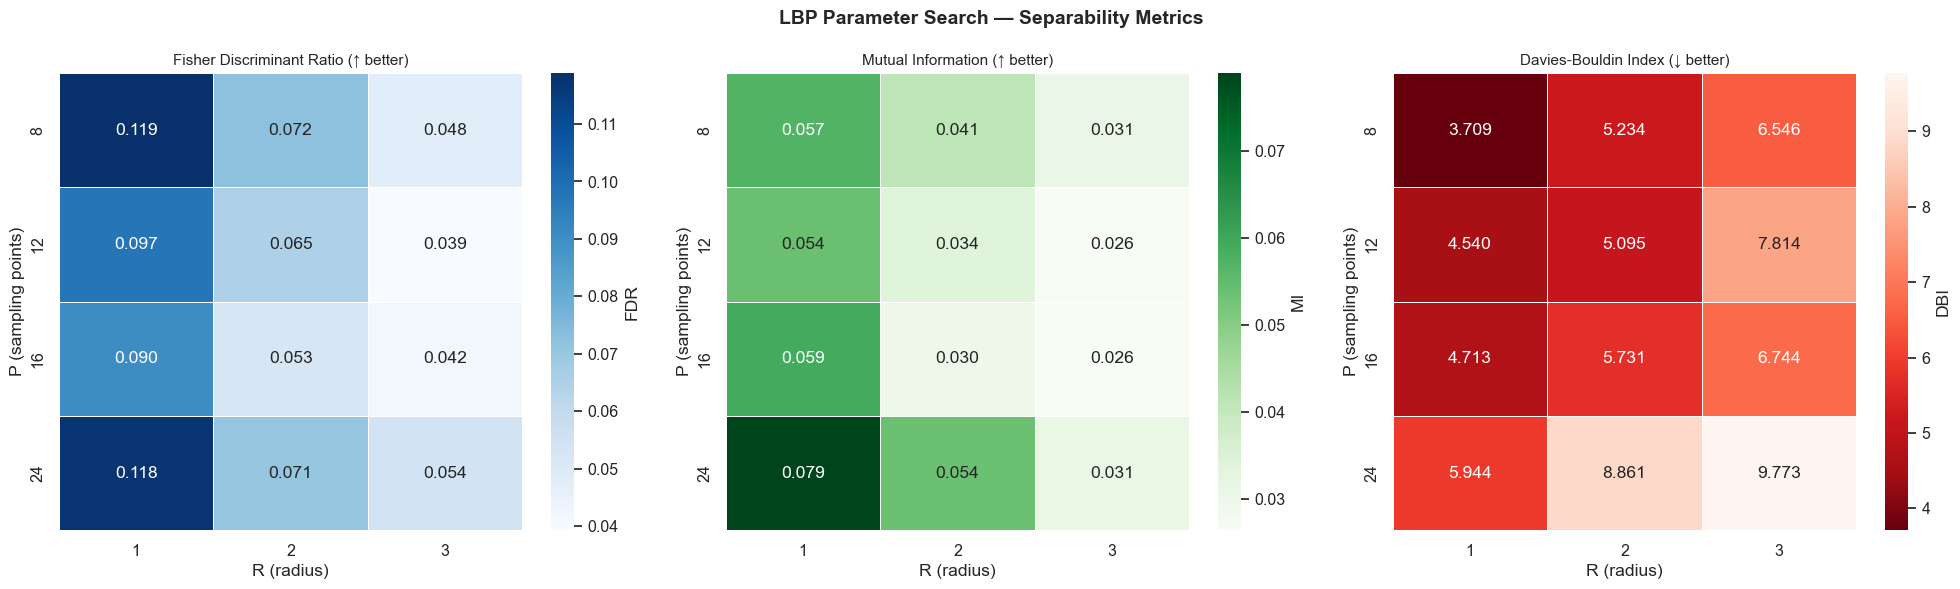

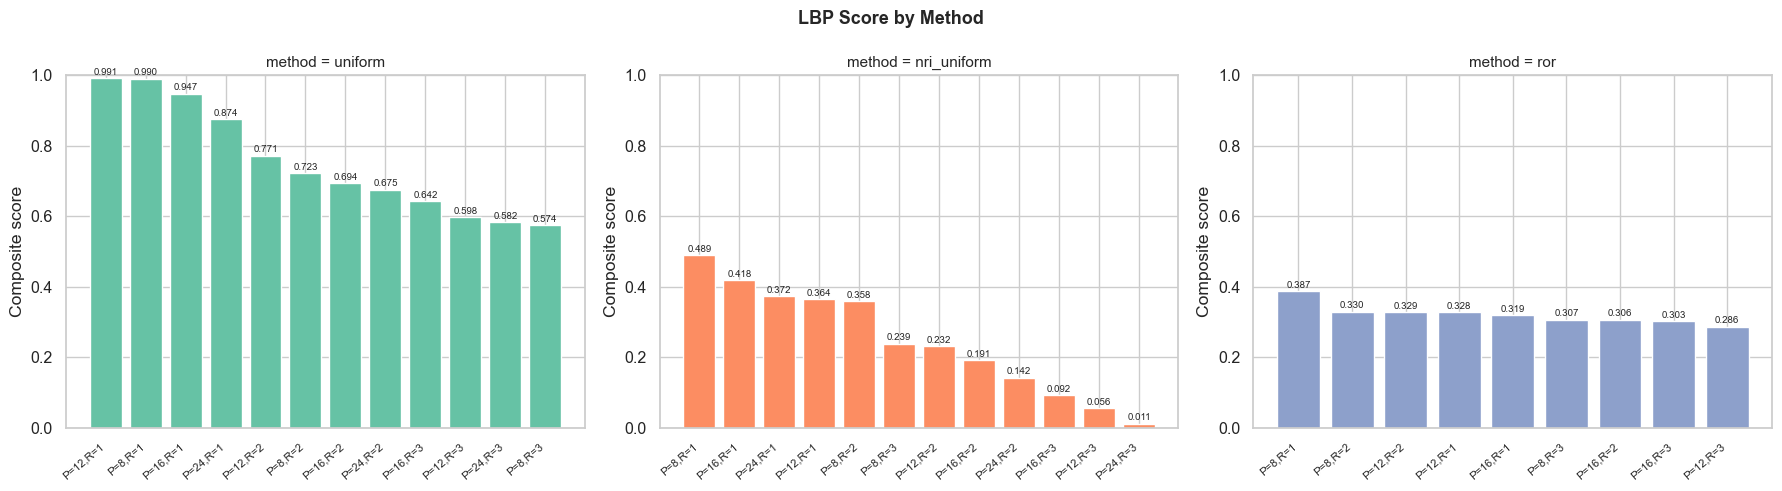

Saved: lbp_param_search.png, lbp_by_method.png


In [54]:
# ── LBP visualisation ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("LBP Parameter Search — Separability Metrics", fontsize=14, fontweight="bold")

for ax, (met, title, cmap) in zip(axes, [
        ("FDR","Fisher Discriminant Ratio (↑ better)","Blues"),
        ("MI", "Mutual Information (↑ better)",       "Greens"),
        ("DBI","Davies-Bouldin Index (↓ better)",     "Reds")]):

    piv = lbp_df.groupby(["P","R"])[met].mean().unstack()
    inv = (met == "DBI")
    sns.heatmap(piv, ax=ax, cmap=cmap+"_r" if inv else cmap,
                annot=True, fmt=".3f", linewidths=0.5,
                cbar_kws={"label": met})
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("R (radius)")
    ax.set_ylabel("P (sampling points)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lbp_param_search.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Score by method ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(LBP_GRID["method"]), figsize=(18, 5), sharey=False)
fig.suptitle("LBP Score by Method", fontsize=13, fontweight="bold")
method_colors = sns.color_palette("Set2", len(LBP_GRID["method"]))

for ax, (method, color) in zip(axes, zip(LBP_GRID["method"], method_colors)):
    sub = lbp_df[lbp_df["method"]==method].sort_values("score", ascending=False)
    bars = ax.bar(range(len(sub)), sub["score"], color=color, edgecolor="white")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels([f"P={r['P']},R={r['R']}" for _, r in sub.iterrows()],
                       rotation=40, ha="right", fontsize=8)
    ax.set_title(f"method = {method}", fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Composite score")
    ax.bar_label(bars, fmt="%.3f", fontsize=7, padding=1)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lbp_by_method.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: lbp_param_search.png, lbp_by_method.png")


## 8. Phase 1C — DWT Parameter Selection

In [55]:
print("Scanning DWT parameter space …")
dwt_rows = []

configs_dwt = list(itertools.product(DWT_GRID["wavelet"], DWT_GRID["level"]))
print(f"Total DWT configurations: {len(configs_dwt)}")

for wavelet, level in tqdm(configs_dwt, desc="DWT"):
    label = f"wavelet={wavelet:8s} level={level}"
    try:
        X_feat  = extract_dwt(X_train_raw, wavelet, level)
        metrics = evaluate_features(X_feat, y_train)
        dwt_rows.append({
            "wavelet":    wavelet,
            "level":      level,
            "n_features": X_feat.shape[1],
            "label":      label,
            **metrics,
        })
    except Exception as e:
        print(f"  SKIP {label}: {e}")

dwt_df = pd.DataFrame(dwt_rows)

mms = MinMaxScaler()
dwt_df["FDR_n"] = mms.fit_transform(dwt_df[["FDR"]])
dwt_df["MI_n"]  = mms.fit_transform(dwt_df[["MI"]])
dwt_df["DBI_n"] = 1 - mms.fit_transform(dwt_df[["DBI"]])
dwt_df["score"] = (dwt_df["FDR_n"] + dwt_df["MI_n"] + dwt_df["DBI_n"]) / 3
dwt_df = dwt_df.sort_values("score", ascending=False).reset_index(drop=True)

print("\nAll DWT configurations (sorted by score):")
display(dwt_df[["wavelet","level","n_features","FDR","MI","DBI","score"]].round(4))

best_dwt = dwt_df.iloc[0]
BEST_DWT_WAV   = str(best_dwt["wavelet"])
BEST_DWT_LEVEL = int(best_dwt["level"])

print(f"\n✓ Best DWT config:")
print(f"  wavelet : {BEST_DWT_WAV}")
print(f"  level   : {BEST_DWT_LEVEL}")
print(f"  score   : {best_dwt['score']:.4f}")


Scanning DWT parameter space …
Total DWT configurations: 21


DWT:   0%|          | 0/21 [00:00<?, ?it/s]


All DWT configurations (sorted by score):


,wavelet,level,n_features,FDR,MI,DBI,score
0,db2,1,16,0.1878,0.0998,3.8294,0.9837
1,sym2,1,16,0.1878,0.0998,3.8294,0.9837
2,db4,1,16,0.1820,0.1003,3.8161,0.9636
3,coif1,1,16,0.1861,0.0985,3.8618,0.9571
4,bior1.3,1,16,0.1895,0.0959,3.9118,0.9396
5,haar,1,16,0.1797,0.0956,4.0633,0.8602
6,db1,1,16,0.1797,0.0956,4.0633,0.8602
7,coif1,2,28,0.1622,0.0832,4.4118,0.5922
8,sym2,2,28,0.1593,0.0861,4.5293,0.5829
9,db2,2,28,0.1593,0.0861,4.5293,0.5829



✓ Best DWT config:
  wavelet : db2
  level   : 1
  score   : 0.9837


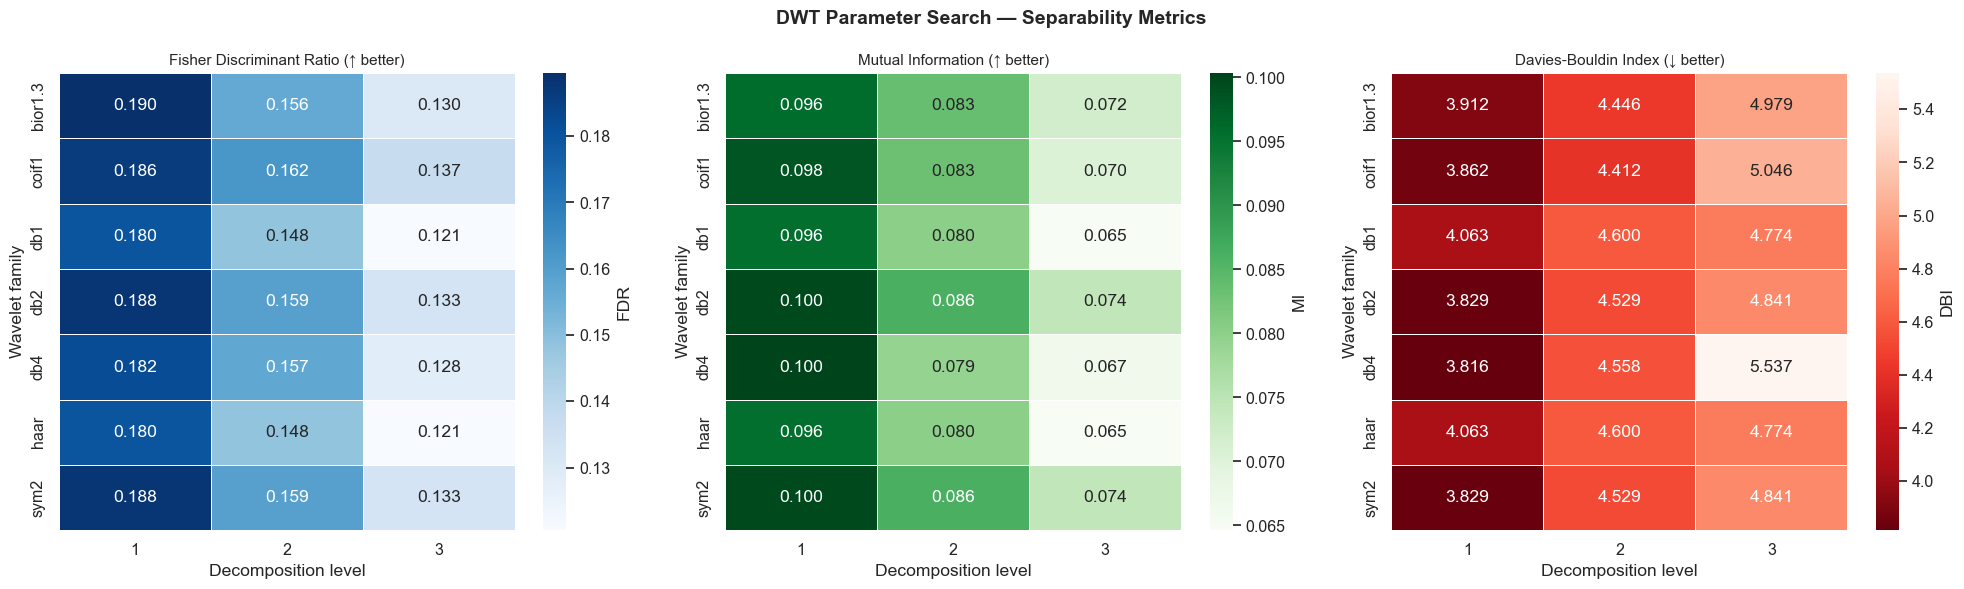

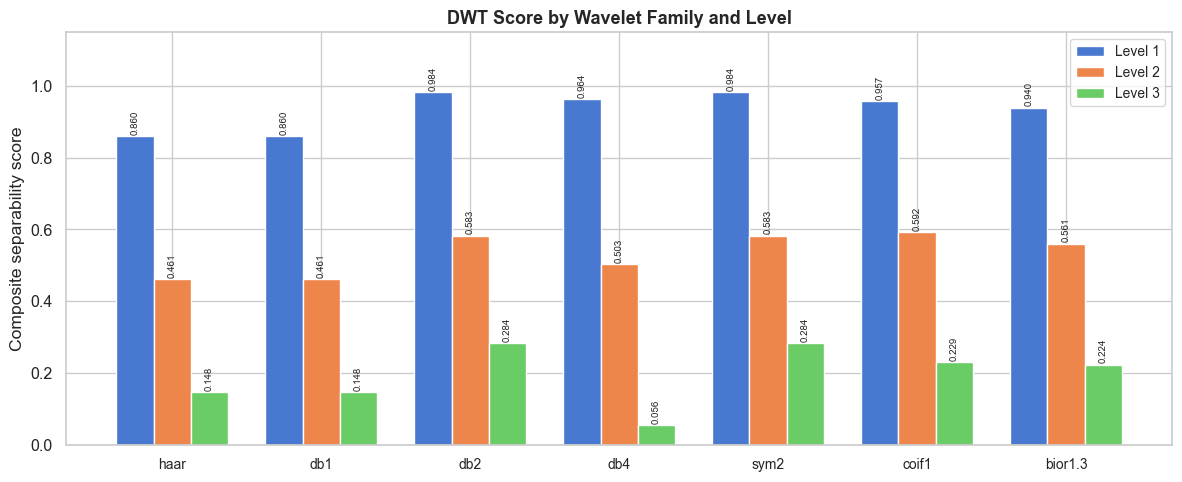

Saved: dwt_param_search.png, dwt_wavelet_comparison.png


In [56]:
# ── DWT visualisation ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("DWT Parameter Search — Separability Metrics", fontsize=14, fontweight="bold")

for ax, (met, title, cmap) in zip(axes, [
        ("FDR","Fisher Discriminant Ratio (↑ better)","Blues"),
        ("MI", "Mutual Information (↑ better)",       "Greens"),
        ("DBI","Davies-Bouldin Index (↓ better)",     "Reds")]):

    piv = dwt_df.pivot(index="wavelet", columns="level", values=met)
    inv = (met == "DBI")
    sns.heatmap(piv, ax=ax, cmap=cmap+"_r" if inv else cmap,
                annot=True, fmt=".3f", linewidths=0.5,
                cbar_kws={"label": met})
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Decomposition level")
    ax.set_ylabel("Wavelet family")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "dwt_param_search.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Score bar chart ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
width = 0.25
wavelets = DWT_GRID["wavelet"]
levels   = DWT_GRID["level"]
lev_colors = sns.color_palette("muted", len(levels))
x = np.arange(len(wavelets))

for li, (lv, col) in enumerate(zip(levels, lev_colors)):
    vals = [dwt_df[(dwt_df.wavelet==wv)&(dwt_df.level==lv)]["score"].values[0]
            if len(dwt_df[(dwt_df.wavelet==wv)&(dwt_df.level==lv)])>0 else 0
            for wv in wavelets]
    bars = ax.bar(x + (li - len(levels)/2 + 0.5)*width, vals, width,
                  label=f"Level {lv}", color=col, edgecolor="white")
    ax.bar_label(bars, fmt="%.3f", fontsize=7, padding=1, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(wavelets, fontsize=10)
ax.set_ylabel("Composite separability score")
ax.set_title("DWT Score by Wavelet Family and Level", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "dwt_wavelet_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: dwt_param_search.png, dwt_wavelet_comparison.png")


## 9. Phase 1 Summary — Selected Parameters

PHASE 1 COMPLETE — OPTIMAL FEATURE PARAMETERS SELECTED

GLCM:
  distances  : [1, 2, 4, 8]
  angles     : [0]
  levels     : 256
  symmetric  : False
  score      : 0.7564

LBP:
  P          : 12
  R          : 1
  method     : uniform
  score      : 0.9906

DWT:
  wavelet    : db2
  level      : 1
  score      : 0.9837


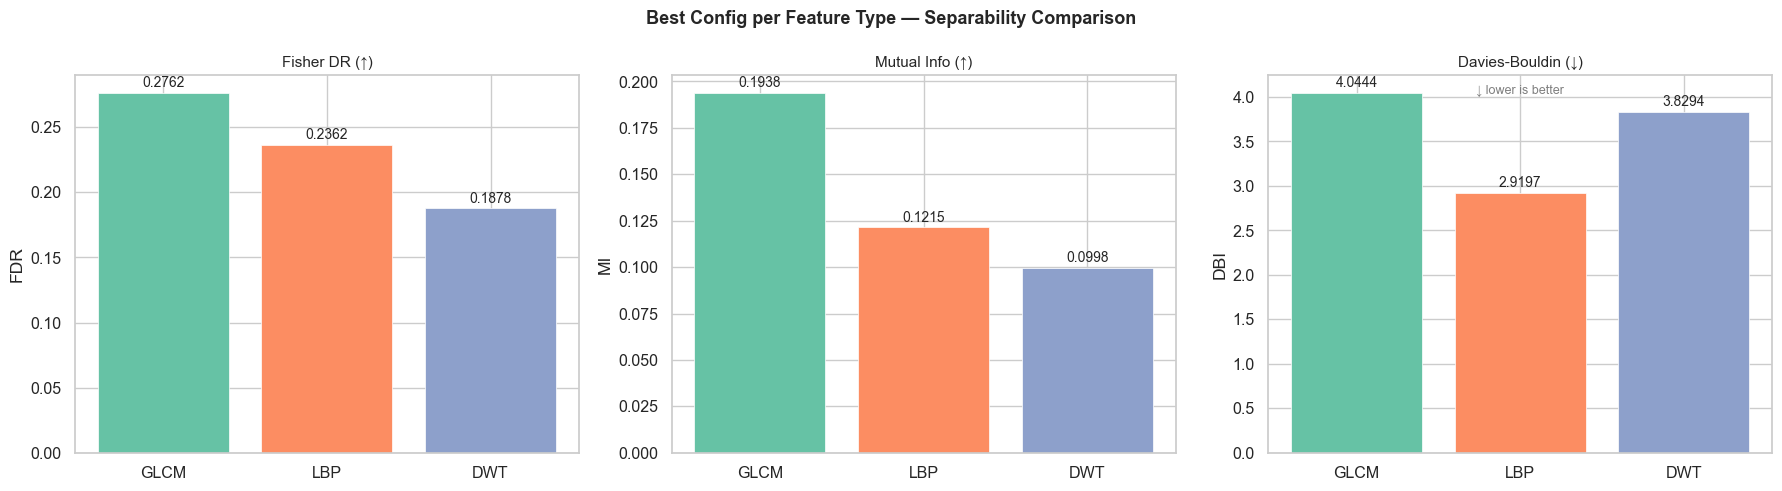

In [57]:
print("=" * 65)
print("PHASE 1 COMPLETE — OPTIMAL FEATURE PARAMETERS SELECTED")
print("=" * 65)

print(f"\nGLCM:")
print(f"  distances  : {BEST_GLCM_DIST}")
print(f"  angles     : {[round(a,4) for a in BEST_GLCM_ANG]}")
print(f"  levels     : {BEST_GLCM_LVL}")
print(f"  symmetric  : {BEST_GLCM_SYM}")
print(f"  score      : {glcm_df.iloc[0]['score']:.4f}")

print(f"\nLBP:")
print(f"  P          : {BEST_LBP_P}")
print(f"  R          : {BEST_LBP_R}")
print(f"  method     : {BEST_LBP_METHOD}")
print(f"  score      : {lbp_df.iloc[0]['score']:.4f}")

print(f"\nDWT:")
print(f"  wavelet    : {BEST_DWT_WAV}")
print(f"  level      : {BEST_DWT_LEVEL}")
print(f"  score      : {dwt_df.iloc[0]['score']:.4f}")

# ── Cross-feature comparison ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Best Config per Feature Type — Separability Comparison",
             fontsize=13, fontweight="bold")

feat_labels = ["GLCM", "LBP", "DWT"]
feat_scores = [glcm_df.iloc[0], lbp_df.iloc[0], dwt_df.iloc[0]]
met_names   = ["FDR", "MI", "DBI"]
met_titles  = ["Fisher DR (↑)", "Mutual Info (↑)", "Davies-Bouldin (↓)"]
colors      = sns.color_palette("Set2", 3)

for ax, (mname, mtitle) in zip(axes, zip(met_names, met_titles)):
    vals = [r[mname] for r in feat_scores]
    bars = ax.bar(feat_labels, vals, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_title(mtitle, fontsize=11)
    ax.set_ylabel(mname)
    ax.bar_label(bars, fmt="%.4f", fontsize=10, padding=2)
    if mname == "DBI":
        # Add annotation: lower is better
        ax.annotate("↓ lower is better", xy=(0.5, 0.95),
                    xycoords="axes fraction", ha="center",
                    fontsize=9, color="gray")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase1_summary.png", dpi=120, bbox_inches="tight")
plt.show()


## 10. Phase 2 — Build Optimal Features & Run Model Benchmark

Now that optimal parameters are selected we:
1. Extract features using best GLCM, LBP, DWT parameters
2. Also compute HOG and first-order stats (no free parameters to tune)
3. Fuse all branches
4. Run GridSearchCV for SVM, KNN, RF
5. Produce a final performance dashboard


Extracting features with OPTIMAL parameters …
Loading features from cache: cache\brain_tumor\features_dde4e9f842.npz

Feature sizes (train):
  A (Stats)  : 11
  B (Tex)    : 20  (GLCM=6 + LBP=14)
  C (DWT)    : 16
  D (HOG)    : 8100
  FULL fused : 8147


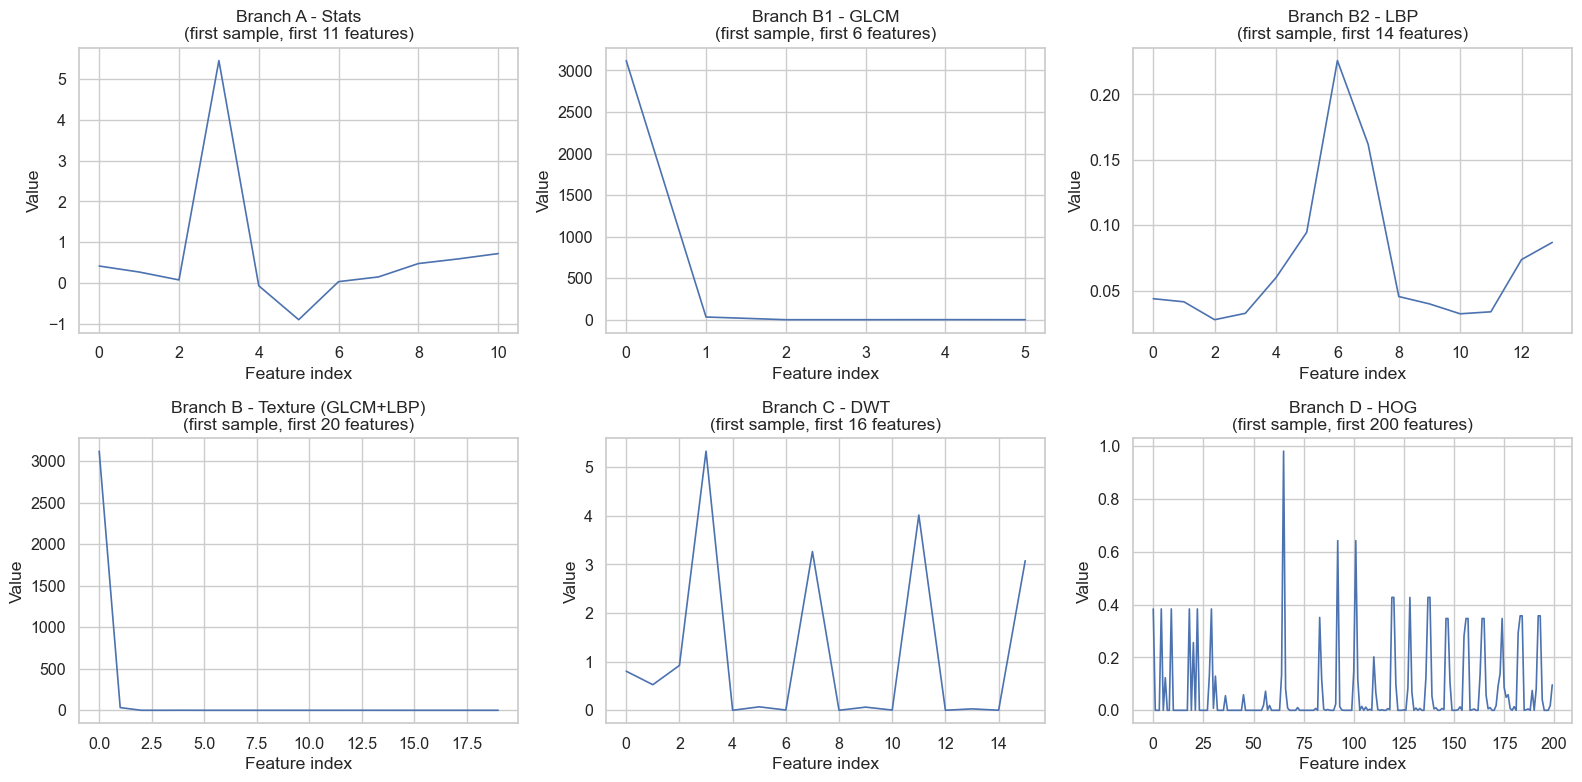

,Branch,n_features,train_mean,train_std
0,A_Stats,11,0.689342,1.654999
1,B_Texture,20,185.975327,809.205688
2,C_DWT,16,1.220982,1.838821
3,D_HOG,8100,0.123538,0.111876
4,FULL,8147,0.582703,41.135208


In [58]:
print("Extracting features with OPTIMAL parameters …")

# ── First-order stats (no tunable params) ────────────────────────────────
def feat_stats(img):
    v = img.ravel()
    h, _ = np.histogram(v, bins=64, range=(0,1), density=True)
    h = (h+1e-12); h /= h.sum()
    ent = -(h*np.log2(h)).sum()
    p10,p25,p50,p75,p90 = np.percentile(v, [10,25,50,75,90])
    return np.array([v.mean(),v.std(),v.var(),ent,skew(v),kurtosis(v),
                     p10,p25,p50,p75,p90], np.float32)

def feat_hog(img):
    return hog(img, orientations=9, pixels_per_cell=(8,8),
               cells_per_block=(2,2), block_norm="L2-Hys",
               feature_vector=True).astype(np.float32)

feature_cache_tag = (
    f"feat_glcm{BEST_GLCM_DIST}_{BEST_GLCM_ANG}_{BEST_GLCM_LVL}_{int(BEST_GLCM_SYM)}"
    f"_lbp{BEST_LBP_P}_{BEST_LBP_R}_{BEST_LBP_METHOD}_dwt{BEST_DWT_WAV}_{BEST_DWT_LEVEL}"
)
feature_cache_hash = hashlib.md5(feature_cache_tag.encode("utf-8")).hexdigest()[:10]
feature_cache_path = CACHE_DIR / f"features_{feature_cache_hash}.npz"

if feature_cache_path.exists() and not FORCE_RECOMPUTE_CACHE:
    print(f"Loading features from cache: {feature_cache_path}")
    ft = np.load(feature_cache_path)
    A_tr, A_te = ft["A_tr"], ft["A_te"]
    B_glcm_tr, B_glcm_te = ft["B_glcm_tr"], ft["B_glcm_te"]
    B_lbp_tr, B_lbp_te = ft["B_lbp_tr"], ft["B_lbp_te"]
    B_tr, B_te = ft["B_tr"], ft["B_te"]
    C_tr, C_te = ft["C_tr"], ft["C_te"]
    D_tr, D_te = ft["D_tr"], ft["D_te"]
    FULL_tr, FULL_te = ft["FULL_tr"], ft["FULL_te"]
else:
    # ── Extract all branches ───────────────────────────────────────────────
    print("  Branch A: Stats …")
    A_tr = np.vstack([feat_stats(x) for x in tqdm(X_train_raw)])
    A_te = np.vstack([feat_stats(x) for x in tqdm(X_test_raw)])

    print("  Branch B: GLCM (optimal params) …")
    B_glcm_tr = extract_glcm(X_train_raw, BEST_GLCM_DIST, BEST_GLCM_ANG,
                             BEST_GLCM_LVL, BEST_GLCM_SYM)
    B_glcm_te = extract_glcm(X_test_raw,  BEST_GLCM_DIST, BEST_GLCM_ANG,
                             BEST_GLCM_LVL, BEST_GLCM_SYM)

    print("  Branch B: LBP (optimal params) …")
    B_lbp_tr = extract_lbp(X_train_raw, BEST_LBP_P, BEST_LBP_R, BEST_LBP_METHOD)
    B_lbp_te = extract_lbp(X_test_raw,  BEST_LBP_P, BEST_LBP_R, BEST_LBP_METHOD)

    # Combine GLCM + LBP into Branch B
    B_tr = np.hstack([B_glcm_tr, B_lbp_tr]).astype(np.float32)
    B_te = np.hstack([B_glcm_te, B_lbp_te]).astype(np.float32)

    print("  Branch C: DWT (optimal params) …")
    C_tr = extract_dwt(X_train_raw, BEST_DWT_WAV, BEST_DWT_LEVEL)
    C_te = extract_dwt(X_test_raw,  BEST_DWT_WAV, BEST_DWT_LEVEL)

    print("  Branch D: HOG …")
    D_tr = np.vstack([feat_hog(x) for x in tqdm(X_train_raw)])
    D_te = np.vstack([feat_hog(x) for x in tqdm(X_test_raw)])

    # Full fusion
    FULL_tr = np.hstack([A_tr, B_tr, C_tr, D_tr]).astype(np.float32)
    FULL_te = np.hstack([A_te, B_te, C_te, D_te]).astype(np.float32)

    np.savez_compressed(
        feature_cache_path,
        A_tr=A_tr, A_te=A_te,
        B_glcm_tr=B_glcm_tr, B_glcm_te=B_glcm_te,
        B_lbp_tr=B_lbp_tr, B_lbp_te=B_lbp_te,
        B_tr=B_tr, B_te=B_te,
        C_tr=C_tr, C_te=C_te,
        D_tr=D_tr, D_te=D_te,
        FULL_tr=FULL_tr, FULL_te=FULL_te,
    )
    print(f"Saved feature cache: {feature_cache_path}")

print(f"\nFeature sizes (train):")
print(f"  A (Stats)  : {A_tr.shape[1]}")
print(f"  B (Tex)    : {B_tr.shape[1]}  (GLCM={B_glcm_tr.shape[1]} + LBP={B_lbp_tr.shape[1]})")
print(f"  C (DWT)    : {C_tr.shape[1]}")
print(f"  D (HOG)    : {D_tr.shape[1]}")
print(f"  FULL fused : {FULL_tr.shape[1]}")

# ── Feature extraction plotting for each branch ──────────────────────────
def plot_feature_preview(ax, X, title, max_points=200):
    n_show = min(max_points, X.shape[1])
    ax.plot(X[0, :n_show], lw=1.2)
    ax.set_title(f"{title}\n(first sample, first {n_show} features)")
    ax.set_xlabel("Feature index")
    ax.set_ylabel("Value")

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
plot_feature_preview(axes[0, 0], A_tr, "Branch A - Stats")
plot_feature_preview(axes[0, 1], B_glcm_tr, "Branch B1 - GLCM")
plot_feature_preview(axes[0, 2], B_lbp_tr, "Branch B2 - LBP")
plot_feature_preview(axes[1, 0], B_tr, "Branch B - Texture (GLCM+LBP)")
plot_feature_preview(axes[1, 1], C_tr, "Branch C - DWT")
plot_feature_preview(axes[1, 2], D_tr, "Branch D - HOG")
plt.tight_layout()
plt.show()

# Distribution summary by branch (mean +/- std)
branch_stats = pd.DataFrame({
    "Branch": ["A_Stats", "B_Texture", "C_DWT", "D_HOG", "FULL"],
    "n_features": [A_tr.shape[1], B_tr.shape[1], C_tr.shape[1], D_tr.shape[1], FULL_tr.shape[1]],
    "train_mean": [A_tr.mean(), B_tr.mean(), C_tr.mean(), D_tr.mean(), FULL_tr.mean()],
    "train_std": [A_tr.std(), B_tr.std(), C_tr.std(), D_tr.std(), FULL_tr.std()],
})

display(branch_stats)


In [59]:
# ── Cleaning pipeline ─────────────────────────────────────────────────────
def clean_scale(Xtr, Xte, corr_thr=0.95):
    vt = VarianceThreshold(0.0)
    Xtr = vt.fit_transform(Xtr); Xte = vt.transform(Xte)
    if Xtr.shape[1] < 5000:
        corr = pd.DataFrame(Xtr).corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        drop = [c for c in upper.columns if any(upper[c] > corr_thr)]
        if drop:
            keep = np.ones(Xtr.shape[1], dtype=bool)
            keep[np.array(drop, int)] = False
            Xtr, Xte = Xtr[:,keep], Xte[:,keep]
    sc = StandardScaler()
    return sc.fit_transform(Xtr), sc.transform(Xte)

# Feature sets to benchmark in Phase 2
OPT_SETS = {
    "A — Stats":       (A_tr, A_te),
    "B — Tex(opt)":    (B_tr, B_te),
    "C — DWT(opt)":    (C_tr, C_te),
    "D — HOG":         (D_tr, D_te),
    "A+B":             (np.hstack([A_tr,B_tr]), np.hstack([A_te,B_te])),
    "B+C(opt)":        (np.hstack([B_tr,C_tr]), np.hstack([B_te,C_te])),
    "A+B+C(opt)":      (np.hstack([A_tr,B_tr,C_tr]), np.hstack([A_te,B_te,C_te])),
    "Full(opt)":       (FULL_tr, FULL_te),
}

print("Cleaning feature sets …")
CLEAN_OPT = {}
for name, (tr, te) in OPT_SETS.items():
    ct, ce = clean_scale(tr.astype(np.float32), te.astype(np.float32))
    CLEAN_OPT[name] = (ct, ce)
    print(f"  {name:18s}  raw={tr.shape[1]:5d}  cleaned={ct.shape[1]:5d}")


Cleaning feature sets …
  A — Stats           raw=   11  cleaned=    9
  B — Tex(opt)        raw=   20  cleaned=   19
  C — DWT(opt)        raw=   16  cleaned=   12
  D — HOG             raw= 8100  cleaned= 8100
  A+B                 raw=   31  cleaned=   28
  B+C(opt)            raw=   36  cleaned=   31
  A+B+C(opt)          raw=   47  cleaned=   37
  Full(opt)           raw= 8147  cleaned= 8147


In [ ]:
# ── Phase 2 benchmark ─────────────────────────────────────────────────────
# Runs in one shot on: split + cv_1 ... cv_10
from sklearn.model_selection import StratifiedShuffleSplit, cross_val_predict

EVAL_MODES = ["split"] + [f"cv_{k}" for k in range(1, 11)]

ESTIMATORS = {
    "SVM": SVC(random_state=SEED, probability=True),
    "KNN": KNeighborsClassifier(),
    "RF":  RandomForestClassifier(random_state=SEED, n_jobs=-1),
}

def _cv_for_mode(mode):
    if mode == "split":
        return CV
    if mode == "cv_1":
        # sklearn KFold/StratifiedKFold needs n_splits >= 2, so cv_1 uses one stratified shuffle split.
        return StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    if mode.startswith("cv_"):
        k = int(mode.split("_")[1])
        return StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
    raise ValueError(f"Unsupported mode: {mode}")

def run_grid(est, grid, Xtr, Xte, mode):
    cv_obj = _cv_for_mode(mode)
    gs = GridSearchCV(est, grid, scoring="f1_macro", cv=cv_obj,
                      n_jobs=-1, refit=True, return_train_score=False)

    t0 = time.time()
    gs.fit(Xtr, y_train)
    fit_t = time.time() - t0

    if mode == "split":
        t0 = time.time()
        yp = gs.best_estimator_.predict(Xte)
        pred_t = time.time() - t0
        y_eval = y_test
    elif mode == "cv_1":
        # cross_val_predict requires partition-style CV; StratifiedShuffleSplit is not one.
        # For cv_1, evaluate on its single held-out fold directly.
        tr_idx, te_idx = next(cv_obj.split(Xtr, y_train))
        est1 = gs.best_estimator_.__class__(**gs.best_estimator_.get_params())
        est1.fit(Xtr[tr_idx], y_train[tr_idx])
        t0 = time.time()
        yp = est1.predict(Xtr[te_idx])
        pred_t = time.time() - t0
        y_eval = y_train[te_idx]
    else:
        t0 = time.time()
        yp = cross_val_predict(gs.best_estimator_, Xtr, y_train, cv=cv_obj, n_jobs=-1)
        pred_t = time.time() - t0
        y_eval = y_train

    return {
        "eval_mode": mode,
        "best_params":   gs.best_params_,
        "best_cv":       gs.best_score_,
        "cv_results":    pd.DataFrame(gs.cv_results_),
        "y_pred":        yp,
        "acc":  accuracy_score(y_eval, yp),
        "f1m":  f1_score(y_eval, yp, average="macro",    zero_division=0),
        "f1w":  f1_score(y_eval, yp, average="weighted", zero_division=0),
        "prec": precision_score(y_eval, yp, average="macro", zero_division=0),
        "rec":  recall_score(y_eval, yp, average="macro",  zero_division=0),
        "fit_t": fit_t,
        "pred_t": pred_t,
        "estimator": gs.best_estimator_,
    }

print("Running Phase 2 benchmark on all modes …")
print("="*65)

P2_ALL = {}
P2 = {}  # backward compatibility for later cells: keeps split results only
ALL_METRICS_ROWS = []

for mode in EVAL_MODES:
    print(f"\nMode: {mode}")
    print("="*65)
    P2_ALL[mode] = {}

    for fs_name, (Xtr, Xte) in CLEAN_OPT.items():
        print(f"\n{'─'*60}")
        print(f"Feature set: {fs_name}  ({Xtr.shape[1]} features)")
        P2_ALL[mode][fs_name] = {}

        for mn, est in ESTIMATORS.items():
            print(f"  {mn} …", end=" ", flush=True)
            r = run_grid(est.__class__(**est.get_params()), MODEL_GRIDS[mn], Xtr, Xte, mode)
            P2_ALL[mode][fs_name][mn] = r

            # Keep existing downstream notebook cells working on split baseline.
            if mode == "split":
                P2.setdefault(fs_name, {})[mn] = r

            ALL_METRICS_ROWS.append({
                "eval_mode": mode,
                "feature_set": fs_name,
                "model": mn,
                "acc": r["acc"],
                "f1_macro": r["f1m"],
                "f1_weighted": r["f1w"],
                "precision_macro": r["prec"],
                "recall_macro": r["rec"],
                "fit_time_s": r["fit_t"],
                "predict_time_s": r["pred_t"],
                "best_cv": r["best_cv"],
                "best_params": str(r["best_params"]),
            })

            print(f"acc={r['acc']:.3f}  f1={r['f1m']:.3f}  t={r['fit_t']:.1f}s")

PHASE2_ALL_METRICS_DF = pd.DataFrame(ALL_METRICS_ROWS)
PHASE2_ALL_METRICS_DF.to_csv("phase2_all_modes_metrics.csv", index=False)

print("\nBenchmark complete.")
print("Saved: phase2_all_modes_metrics.csv")


Running Phase 2 benchmark on all modes …

Mode: split

────────────────────────────────────────────────────────────
Feature set: A — Stats  (9 features)
  SVM … acc=0.803  f1=0.804  t=8.0s
  KNN … acc=0.737  f1=0.738  t=0.3s
  RF … acc=0.753  f1=0.755  t=7.2s

────────────────────────────────────────────────────────────
Feature set: B — Tex(opt)  (19 features)
  SVM … acc=0.823  f1=0.823  t=5.8s
  KNN … acc=0.763  f1=0.762  t=0.3s
  RF … acc=0.800  f1=0.800  t=7.1s

────────────────────────────────────────────────────────────
Feature set: C — DWT(opt)  (12 features)
  SVM … acc=0.727  f1=0.725  t=4.9s
  KNN … acc=0.683  f1=0.682  t=0.2s
  RF … acc=0.730  f1=0.726  t=6.7s

────────────────────────────────────────────────────────────
Feature set: D — HOG  (8100 features)
  SVM … acc=0.903  f1=0.903  t=729.9s
  KNN … acc=0.837  f1=0.833  t=20.7s
  RF … acc=0.803  f1=0.802  t=52.7s

────────────────────────────────────────────────────────────
Feature set: A+B  (28 features)
  SVM … acc=0.8

## 11. Per-Feature-Set Result Plots

In [ ]:
def _hp_label(row, mn):
    if mn=="SVM":
        k = row.get('param_kernel', '?')
        c = row.get('param_C', '?')
        g = row.get('param_gamma', '?')
        return f"{k} C={c} gamma={g}" if k == "rbf" else f"{k} C={c}"
    if mn=="KNN": return f"k={row.get('param_n_neighbors','?')} {str(row.get('param_metric','?'))[:3]}"
    return f"n={row.get('param_n_estimators','?')} d={row.get('param_max_depth','?')}"

def plot_fs(fs_name, res_dict):
    mnames = ["SVM","KNN","RF"]
    fig    = plt.figure(figsize=(22, 16))
    fig.suptitle(f"Feature Set: {fs_name}  [Optimal Parameters]",
                 fontsize=15, fontweight="bold", y=0.99)
    outer  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45,
                               height_ratios=[1.0, 1.5, 1.1])

    # ── Metric bar chart ──────────────────────────────────────────────────
    ax1 = fig.add_subplot(outer[0])
    mk  = ["acc","f1m","prec","rec"]
    ml  = ["Accuracy","F1-macro","Precision","Recall"]
    x, w = np.arange(4), 0.22
    for i, mn in enumerate(mnames):
        vals = [res_dict[mn][k] for k in mk]
        bars = ax1.bar(x+(i-1)*w, vals, w, label=mn,
                       color=PALETTE[mn], edgecolor="white")
        ax1.bar_label(bars, fmt="%.3f", fontsize=8, padding=1)
    ax1.set_xticks(x); ax1.set_xticklabels(ml)
    ax1.set_ylim(0, 1.15); ax1.set_ylabel("Score")
    ax1.set_title("Best-config Test Metrics", fontsize=11)
    ax1.legend(fontsize=9)
    ax1.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.4)

    # ── HP sensitivity strips ─────────────────────────────────────────────
    inner = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer[1], wspace=0.38)
    for col, mn in enumerate(mnames):
        ax = fig.add_subplot(inner[col])
        cv = res_dict[mn]["cv_results"].sort_values("mean_test_score",ascending=False).head(20)
        cv["label"] = cv.apply(lambda r: _hp_label(r, mn), axis=1)
        yp = np.arange(len(cv))
        ax.barh(yp, cv["mean_test_score"], xerr=cv["std_test_score"],
                color=PALETTE[mn], alpha=0.75, error_kw={"elinewidth":0.8})
        ax.set_yticks(yp); ax.set_yticklabels(cv["label"], fontsize=7)
        ax.set_xlabel("CV F1-macro", fontsize=9)
        ax.set_title(f"{mn} — Top 20 configs", fontsize=10, fontweight="bold")
        ax.set_xlim(0, 1)
        ax.axvline(cv["mean_test_score"].max(), color="red", lw=1.2, ls="--", alpha=0.6)

    # ── Confusion matrices ─────────────────────────────────────────────────
    inner2 = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer[2], wspace=0.38)
    for col, mn in enumerate(mnames):
        ax = fig.add_subplot(inner2[col])
        cm = confusion_matrix(y_test, res_dict[mn]["y_pred"], normalize="true")
        ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
        ax.set_xticklabels(class_names, rotation=35, ha="right", fontsize=8)
        ax.set_yticklabels(class_names, fontsize=8)
        ax.set_xlabel("Predicted", fontsize=8); ax.set_ylabel("True", fontsize=8)
        ax.set_title(f"{mn} — CM", fontsize=10, fontweight="bold")
        for i in range(n_classes):
            for j in range(n_classes):
                ax.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center",
                        fontsize=7, color="white" if cm[i,j]>0.6 else "black")

    fname = OUTPUT_DIR / f"p2_{fs_name.replace(' ','_').replace('+','p')}.png"
    plt.savefig(fname, dpi=110, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")

for fs_name, res_dict in P2.items():
    print(f"\nPlotting: {fs_name}")
    plot_fs(fs_name, res_dict)


## 12. Overall Performance Dashboard

In [ ]:
fs_list = list(P2.keys())
mnames  = ["SVM","KNN","RF"]

fig = plt.figure(figsize=(24, 22))
fig.suptitle("Overall Dashboard — Optimal Feature Parameters + Model Benchmark",
             fontsize=15, fontweight="bold", y=0.99)
outer = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45)

# ── Grouped bar: F1-macro ─────────────────────────────────────────────────
ax1 = fig.add_subplot(outer[0])
x, w = np.arange(len(fs_list)), 0.25
for i, mn in enumerate(mnames):
    vals = [P2[fs][mn]["f1m"] for fs in fs_list]
    bars = ax1.bar(x+(i-1)*w, vals, w, label=mn,
                   color=PALETTE[mn], edgecolor="white")
    ax1.bar_label(bars, fmt="%.3f", fontsize=7.5, padding=1, rotation=90)
ax1.set_xticks(x); ax1.set_xticklabels(fs_list, rotation=20, ha="right", fontsize=9)
ax1.set_ylim(0, 1.20); ax1.set_ylabel("Test F1-macro")
ax1.set_title("Test F1-macro — All Feature Sets × Models (Optimal Params)", fontsize=12, fontweight="bold")
ax1.legend(fontsize=10)
ax1.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.4)

# ── Heatmap: F1-macro ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(outer[1])
hdata = pd.DataFrame(
    {mn: [P2[fs][mn]["f1m"] for fs in fs_list] for mn in mnames},
    index=fs_list)
sns.heatmap(hdata, ax=ax2, annot=True, fmt=".3f", cmap="YlGnBu",
            vmin=0, vmax=1, linewidths=0.5, linecolor="white",
            cbar_kws={"label":"Test F1-macro"})
ax2.set_title("F1-macro Heatmap", fontsize=12, fontweight="bold")
ax2.tick_params(axis="x", rotation=0); ax2.tick_params(axis="y", rotation=0)

# ── Scatter: training time vs F1-macro ────────────────────────────────────
ax3 = fig.add_subplot(outer[2])
for mn in mnames:
    times = [P2[fs][mn]["fit_t"] for fs in fs_list]
    f1s   = [P2[fs][mn]["f1m"]   for fs in fs_list]
    ax3.scatter(times, f1s, s=90, label=mn, color=PALETTE[mn],
                edgecolors="white", zorder=3)
    for fi, fs in enumerate(fs_list):
        ax3.annotate(fs[:9], (times[fi], f1s[fi]),
                     textcoords="offset points", xytext=(4,2), fontsize=6.5)
ax3.set_xlabel("Training time (s)"); ax3.set_ylabel("Test F1-macro")
ax3.set_title("Training Time vs F1-macro Trade-off", fontsize=12, fontweight="bold")
ax3.legend(fontsize=10); ax3.grid(True, alpha=0.3)

plt.savefig(OUTPUT_DIR / "p2_overall_dashboard.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: p2_overall_dashboard.png")


## 13. Leaderboard & Final Summary

In [ ]:
rows = []
for fs in fs_list:
    for mn in mnames:
        r = P2[fs][mn]
        rows.append({"Feature Set":fs, "Model":mn,
                     "Accuracy":r["acc"], "F1-macro":r["f1m"],
                     "F1-weighted":r["f1w"], "Precision":r["prec"],
                     "Recall":r["rec"], "Fit Time (s)":r["fit_t"],
                     "Best Params":str(r["best_params"])})

leader = pd.DataFrame(rows)
mms2 = MinMaxScaler()
leader["time_n"] = mms2.fit_transform(leader[["Fit Time (s)"]])
leader["Composite"] = (0.50*leader["F1-macro"] + 0.30*leader["Accuracy"]
                       + 0.10*leader["Precision"] + 0.10*leader["Recall"]
                       - 0.05*leader["time_n"]).round(4)
leader = leader.sort_values("Composite", ascending=False).reset_index(drop=True)
leader.index += 1

print("LEADERBOARD")
display(leader[["Feature Set","Model","Accuracy","F1-macro",
                "Precision","Recall","Fit Time (s)","Composite"]].round(4))
leader.to_csv("phase2_benchmark_results.csv", index=False)

# ── Leaderboard bar chart ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
top = leader.head(min(20, len(leader)))
bar_cols = [PALETTE[m] for m in top["Model"]]
bars = ax.barh(range(len(top))[::-1], top["Composite"],
               color=bar_cols, edgecolor="white")
ax.set_yticks(range(len(top))[::-1])
ax.set_yticklabels([f"{r['Feature Set']} | {r['Model']}"
                    for _, r in top.iterrows()], fontsize=9)
ax.set_xlabel("Composite Score")
ax.set_title("Final Leaderboard — Optimal Feature Params + Tuned Models",
             fontsize=13, fontweight="bold")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=PALETTE[m],label=m) for m in mnames],
          fontsize=10, loc="lower right")
ax.bar_label(bars, fmt="%.4f", fontsize=8, padding=2)
ax.set_xlim(0, 1.08)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "p2_leaderboard.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nSaved: phase2_benchmark_results.csv, p2_leaderboard.png")


In [ ]:
# ── Final print summary ────────────────────────────────────────────────────
print("=" * 65)
print("FINAL SUMMARY")
print("=" * 65)

best = leader.iloc[0]
print(f"\n🏆  Best overall:")
print(f"     Feature Set : {best['Feature Set']}")
print(f"     Model       : {best['Model']}")
print(f"     Accuracy    : {best['Accuracy']:.4f}")
print(f"     F1-macro    : {best['F1-macro']:.4f}")
print(f"     Composite   : {best['Composite']:.4f}")

print(f"\n📊  Best per model:")
for mn in mnames:
    sub = leader[leader["Model"]==mn].iloc[0]
    print(f"     {mn:4s}  Feature Set: {sub['Feature Set']:20s}  "
          f"F1={sub['F1-macro']:.4f}")

print(f"\n📦  Best per feature set:")
for fs in fs_list:
    sub = leader[leader["Feature Set"]==fs].iloc[0]
    print(f"     {fs:18s}  {sub['Model']:4s}  F1={sub['F1-macro']:.4f}")

print(f"\n⚙️   Optimal feature parameters used:")
print(f"     GLCM: dist={BEST_GLCM_DIST}  ang={len(BEST_GLCM_ANG)} angles  "
      f"lvl={BEST_GLCM_LVL}  sym={BEST_GLCM_SYM}")
print(f"     LBP : P={BEST_LBP_P}  R={BEST_LBP_R}  method={BEST_LBP_METHOD}")
print(f"     DWT : wavelet={BEST_DWT_WAV}  level={BEST_DWT_LEVEL}")

print(f"\n📁  Output files:")
for f in [
          "phase2_benchmark_results.csv",
          "phase2_all_modes_metrics.csv",
          "seed_stability_3seeds.csv",
          "output/class_balance_train.png",
          "output/rf_branch_importance.png",
          "output/tsne_best_feature_set.png",
          "output/glcm_param_search.png", "output/glcm_top15.png",
          "output/lbp_param_search.png", "output/lbp_by_method.png",
          "output/dwt_param_search.png", "output/dwt_wavelet_comparison.png",
          "output/phase1_summary.png",
          "output/p2_overall_dashboard.png", "output/p2_leaderboard.png"]:
    print(f"     {f}")


## 14. Diagnostics: Imbalance, RF Importances, t-SNE, Seed Stability

In [ ]:
from collections import Counter
from sklearn.manifold import TSNE

# -----------------------------------------------------------------------------
# 12) Class imbalance check
# -----------------------------------------------------------------------------
train_counter = Counter(y_train)
imbalance_ratio = max(train_counter.values()) / max(1, min(train_counter.values()))

print("Train class balance:", train_counter)
print(f"Imbalance ratio: {imbalance_ratio:.3f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
cls_idx = list(range(len(class_names)))
cls_counts = [train_counter.get(i, 0) for i in cls_idx]
bars = ax.bar(class_names, cls_counts, color=sns.color_palette("Set2", len(class_names)))
ax.set_title("Train Class Distribution")
ax.set_ylabel("Count")
ax.set_xlabel("Class")
ax.bar_label(bars, padding=2)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_balance_train.png", dpi=120, bbox_inches="tight")
plt.show()

if imbalance_ratio >= 1.5:
    print("Note: noticeable imbalance detected. Consider trying class_weight and/or SMOTE in a controlled experiment.")
else:
    print("Class balance looks reasonably even. SMOTE likely optional.")

# -----------------------------------------------------------------------------
# 13) RF branch importance visualisation (A / GLCM / LBP / DWT / HOG)
# -----------------------------------------------------------------------------
rf_full = RandomForestClassifier(
    random_state=SEED,
    n_jobs=-1,
    **P2["Full(opt)"]["RF"]["best_params"]
)
rf_full.fit(FULL_tr, y_train)

importances = rf_full.feature_importances_
a = A_tr.shape[1]
bg = B_glcm_tr.shape[1]
bl = B_lbp_tr.shape[1]
c = C_tr.shape[1]
d = D_tr.shape[1]

branch_importance = {
    "A_Stats": float(importances[:a].sum()),
    "B_GLCM": float(importances[a:a+bg].sum()),
    "B_LBP": float(importances[a+bg:a+bg+bl].sum()),
    "C_DWT": float(importances[a+bg+bl:a+bg+bl+c].sum()),
    "D_HOG": float(importances[a+bg+bl+c:a+bg+bl+c+d].sum()),
}
branch_imp_df = pd.DataFrame(
    {"branch": list(branch_importance.keys()), "importance": list(branch_importance.values())}
).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.bar(branch_imp_df["branch"], branch_imp_df["importance"], color=sns.color_palette("viridis", len(branch_imp_df)))
ax.set_title("RF Branch Importances (trained on Full(opt))")
ax.set_ylabel("Summed feature_importances_")
ax.set_xlabel("Feature branch")
ax.bar_label(bars, fmt="%.3f", padding=2)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rf_branch_importance.png", dpi=120, bbox_inches="tight")
plt.show()

display(branch_imp_df)

# -----------------------------------------------------------------------------
# 14) t-SNE on best feature set
# -----------------------------------------------------------------------------
best_fs_tsne = leader.iloc[0]["Feature Set"]
X_best_train = CLEAN_OPT[best_fs_tsne][0]

n_tsne = min(500, X_best_train.shape[0])
rng = np.random.default_rng(SEED)
idx_tsne = rng.choice(X_best_train.shape[0], size=n_tsne, replace=False)
X_tsne = X_best_train[idx_tsne]
y_tsne = y_train[idx_tsne]

Xr = TSNE(n_components=2, random_state=SEED, init="pca", learning_rate="auto").fit_transform(X_tsne)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(Xr[:, 0], Xr[:, 1], c=y_tsne, cmap="tab10", s=18, alpha=0.85)
ax.set_title(f"t-SNE projection (best feature set: {best_fs_tsne}, n={n_tsne})")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
handles, _ = sc.legend_elements()
ax.legend(handles, class_names, title="Class", bbox_to_anchor=(1.03, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "tsne_best_feature_set.png", dpi=120, bbox_inches="tight")
plt.show()

# -----------------------------------------------------------------------------
# 15) Seed stability check (3 seeds)
# -----------------------------------------------------------------------------
best_fs = leader.iloc[0]["Feature Set"]
best_model = leader.iloc[0]["Model"]

X_raw = np.vstack([OPT_SETS[best_fs][0], OPT_SETS[best_fs][1]])
y_all_diag = np.concatenate([y_train, y_test])

seed_results = []
for sd in [SEED, SEED + 1, SEED + 2]:
    Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(
        X_raw, y_all_diag, test_size=TEST_SIZE, stratify=y_all_diag, random_state=sd
    )
    Xtr_s, Xte_s = clean_scale(Xtr_s.astype(np.float32), Xte_s.astype(np.float32))

    cv_s = StratifiedKFold(n_splits=3, shuffle=True, random_state=sd)
    est_s = ESTIMATORS[best_model].__class__(**ESTIMATORS[best_model].get_params())

    gs_s = GridSearchCV(
        est_s,
        MODEL_GRIDS[best_model],
        scoring="f1_macro",
        cv=cv_s,
        n_jobs=-1,
        refit=True,
        return_train_score=False,
    )
    gs_s.fit(Xtr_s, ytr_s)
    yp_s = gs_s.best_estimator_.predict(Xte_s)

    seed_results.append({
        "seed": sd,
        "acc": accuracy_score(yte_s, yp_s),
        "f1_macro": f1_score(yte_s, yp_s, average="macro", zero_division=0),
        "best_params": str(gs_s.best_params_),
    })

seed_df = pd.DataFrame(seed_results)
mu = seed_df["f1_macro"].mean()
sig = seed_df["f1_macro"].std(ddof=1) if len(seed_df) > 1 else 0.0
ci95 = 1.96 * sig / np.sqrt(len(seed_df)) if len(seed_df) > 1 else 0.0

print(f"\nSeed stability for best pair ({best_fs}, {best_model}):")
print(seed_df.to_string(index=False))
print(f"F1-macro mean ± 95% CI: {mu:.4f} ± {ci95:.4f}")

seed_df.to_csv("seed_stability_3seeds.csv", index=False)
print("Saved: class_balance_train.png, rf_branch_importance.png, tsne_best_feature_set.png, seed_stability_3seeds.csv")

In [ ]:
# ── Inference test on a random test image ─────────────────────────────────
# Uses the globally best model from Phase 2 benchmark (highest F1-macro).

# 1) Find best (feature set, model) pair
best_fs_name, best_model_name, best_f1 = None, None, -np.inf
for fs_name, model_dict in P2.items():
    for model_name, result in model_dict.items():
        if result["f1m"] > best_f1:
            best_f1 = result["f1m"]
            best_fs_name = fs_name
            best_model_name = model_name

best_result = P2[best_fs_name][best_model_name]
best_estimator = best_result["estimator"]

# 2) Pick a random sample from test set
rng = np.random.default_rng(SEED)
idx = int(rng.integers(0, len(y_test)))
img = X_test_raw[idx]
y_true = int(y_test[idx])

# 3) Build input vector from the matching cleaned feature matrix
Xte_best = CLEAN_OPT[best_fs_name][1]
x_input = Xte_best[idx:idx+1]

# 4) Predict
y_pred = int(best_estimator.predict(x_input)[0])

if hasattr(best_estimator, "predict_proba"):
    proba = best_estimator.predict_proba(x_input)[0]
    conf = float(proba[y_pred])
else:
    conf = np.nan

# 5) Display result
plt.figure(figsize=(4.5, 4.5))
plt.imshow(img, cmap="gray")
plt.axis("off")

true_name = class_names[y_true]
pred_name = class_names[y_pred]
correct = (y_true == y_pred)
status = "CORRECT" if correct else "WRONG"

if np.isfinite(conf):
    title = (
        f"Random test inference ({status})\n"
        f"Best model: {best_model_name} on '{best_fs_name}' (F1={best_f1:.3f})\n"
        f"True: {true_name} | Pred: {pred_name} | Conf: {conf:.3f}"
    )
else:
    title = (
        f"Random test inference ({status})\n"
        f"Best model: {best_model_name} on '{best_fs_name}' (F1={best_f1:.3f})\n"
        f"True: {true_name} | Pred: {pred_name}"
    )

plt.title(title, fontsize=10)
plt.tight_layout()
plt.show()

print("Selected test index:", idx)
print("Best feature set:", best_fs_name)
print("Best model:", best_model_name)
print("True label:", true_name)
print("Predicted label:", pred_name)
if np.isfinite(conf):
    print("Prediction confidence:", f"{conf:.4f}")
